In [2]:
!pip install scikit-learn matplotlib pandas numpy


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('dummy_data.csv')

In [5]:
df.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Target
0,1.262584,0.932591,-0.399636,0.224685,-1.760809,1.726964,-0.372833,0.722381,-1.525656,-1.418366,90.979556
1,-0.295480,-0.370011,-0.109610,-0.088363,1.598647,-0.436386,0.006422,0.546284,0.560919,-0.258796,1.057309
2,-0.692421,-1.320023,0.194607,-0.742471,-0.037037,-0.622649,1.695051,0.043602,-0.429302,-0.611769,-95.021276
3,-1.406661,-0.725744,0.026091,0.517659,-0.755383,-0.624819,-1.279577,-1.840874,-0.611518,0.186767,-69.627624
4,-2.872262,-1.594703,-0.147603,-0.466037,-0.532701,0.323168,-1.768439,0.140886,-1.169917,0.513600,-12.775267


In [6]:
X = df.drop(columns='Target')
y = df['Target']

In [7]:
df.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Target
0,1.262584,0.932591,-0.399636,0.224685,-1.760809,1.726964,-0.372833,0.722381,-1.525656,-1.418366,90.979556
1,-0.295480,-0.370011,-0.109610,-0.088363,1.598647,-0.436386,0.006422,0.546284,0.560919,-0.258796,1.057309
2,-0.692421,-1.320023,0.194607,-0.742471,-0.037037,-0.622649,1.695051,0.043602,-0.429302,-0.611769,-95.021276
3,-1.406661,-0.725744,0.026091,0.517659,-0.755383,-0.624819,-1.279577,-1.840874,-0.611518,0.186767,-69.627624
4,-2.872262,-1.594703,-0.147603,-0.466037,-0.532701,0.323168,-1.768439,0.140886,-1.169917,0.513600,-12.775267


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=1.0)

In [10]:
ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)

Lasso()

In [11]:
ridge_pred = ridge.predict(X_test)
lasso_pred = lasso.predict(X_test)

In [13]:
models = ['Ridge', 'Lasso']
mse = [mean_squared_error(y_test, ridge_pred), mean_squared_error(y_test, lasso_pred)]
r2 = [r2_score(y_test, ridge_pred), r2_score(y_test, lasso_pred)]

In [14]:
print("\n Model Performance Comparison:")
for name, m, r in zip(models, mse, r2):
    print(f"{name} Regression -> MSE: {m:.2f}, R²: {r:.2f}")


 Model Performance Comparison:
Ridge Regression -> MSE: 186.72, R²: 0.97
Lasso Regression -> MSE: 196.16, R²: 0.97


In [15]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Ridge Coef': ridge.coef_,
    'Lasso Coef': lasso.coef_
})

In [16]:
print(coefficients)

      Feature  Ridge Coef  Lasso Coef
0   Feature_1    1.182230    0.223567
1   Feature_2   -1.401594   -0.314332
2   Feature_3    7.990868    6.906713
3   Feature_4   79.633912   79.381800
4   Feature_5    0.779250    0.000000
5   Feature_6   35.765706   35.302893
6   Feature_7    8.080239    7.314339
7   Feature_8   40.468079   39.343425
8   Feature_9    0.917898    0.000000
9  Feature_10   -0.854186   -0.000000


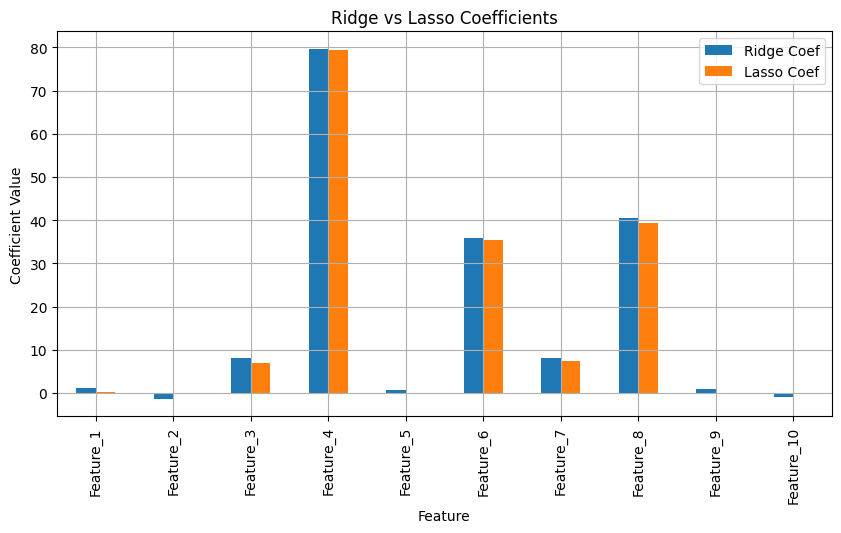

In [17]:
coefficients.plot(x='Feature', kind='bar', figsize=(10,5))
plt.title('Ridge vs Lasso Coefficients')
plt.ylabel('Coefficient Value')
plt.grid(True)
plt.show()